## 3. Applying wavefront errors to retinal images

In [1]:
import numpy
import matplotlib.pylab as plt
from tqdm import tqdm, trange, tqdm_notebook
from astropy.io import fits
%matplotlib inline
import aotools

from IPython.display import HTML
import matplotlib.colors as colors
import PIL.Image as Image

import scipy.signal
j = 0+1j

In [2]:
fitsdata = fits.open('tabai5mm.fits')
data=fitsdata[0].data

wavelength=833e-3 #(this is the wavelength data was taken at in microns)
wavelength_m=833e-9 #(wavelength in metres - we'll use this later)
diameter=5e-3 #(pupil diameter in m)

data[:,:,0:2]=0 #remove piston, tip and tilt again

array_size=128

oversampling = 2

When imaging the retina, it is important to know how residual wavefront errors may affect the final image obtained.  If our final images are poor, we may be unable to carry out analyses such as cone counting.





Typically we image over a 1-2$^{\circ}$ square patch of retina.  We make the assumption that the optical system is isoplanatic - so the PSF is the same for all points in the square patch of retina.

Lets apply the PSF from the first eye in our dataset to an image of the retina.  We can simulate realistic retinal ground truth images using ERICA*; a retinal image simulation tool.  Below is a ground truth image of the retina simulated using a 5mm pupil at the fovea (the central part of the retina with the highest cone density) with a field of view of 2 degrees.

*<i>Laura K. Young and Hannah E. Smithson, "Emulated retinal image capture (ERICA) to test, train and validate processing of retinal images", Sci Rep 11, 11225 (2021)

Number of pixels = 545 x 545


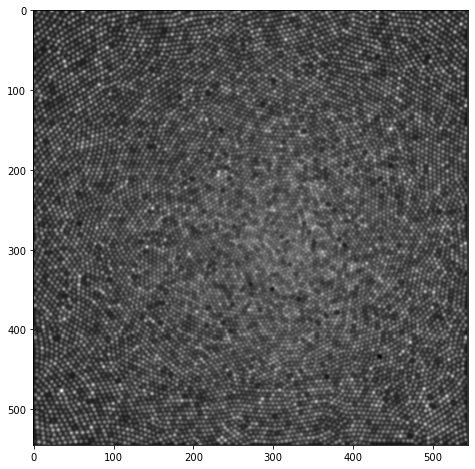

In [3]:
#Open the simulated ground truth retinal image from the GitHub repository
image = Image.open('foveatedretina.bmp')

#Make it a numpy array
image = numpy.array(image) 

#Check that it's square
if image.shape[0] < image.shape[1]:
    image = image[:,:image.shape[0]]
elif image.shape[1] < image.shape[0]:
    image = image[:,:image.shape[0]]

#Show the image
plt.figure(figsize=(8,8))
plt.imshow(image,cmap='gray')

#Find out how many pixels are in the image
print('Number of pixels = %i x %i'%(image.shape[0],image.shape[1]))

We need to check that the scaling of the psf and source image match up.  Let's generate the wavefront at time zero for the first person in the dataset again

In [13]:
firsteye_t0 = (data[0,0,:])
z=aotools.zernikeArray(65,array_size)
zflat=numpy.reshape(z, (z.shape[0],z.shape[1]*z.shape[2]))
wavefront = numpy.dot(firsteye_t0,zflat)
wavefront = numpy.reshape(wavefront, (z.shape[1],z.shape[2]))
wavefront *= aotools.circle(array_size/2, array_size)
wavefront_radians = wavefront*((2*numpy.pi)/wavelength)

Check the scaling of our psf.  The formula to convert from real space pixel scale to fourier domain pixel scale is:

In [15]:
#pixel_scale_wavefront = diameter/array_size (=1/128)
#pixel_scale_psf = 1/(array_size*pixel_scale_wavefront) = 1/(array_size * diameter/array_size) = 1/diameter

pixel_scale_psf = wavelength_m/(oversampling*diameter)
pixel_scale_psf_arcmin = (pixel_scale_psf * 180.0 * 60)/numpy.pi
print('The pixel scale of the psf in arcminutes is: %f'%(pixel_scale_psf_arcmin))

The pixel scale of the psf in arcminutes is: 0.286364


To find the pixel scale of the image in arcminutes - reacll that the field of view is 2 degrees, or 120 arcminutes.

In [8]:
fov_arcmin=120

In [9]:
n_pixels_image=image.shape[0]
pixel_scale_image_arcmin=fov_arcmin/n_pixels_image
print('The pixel scale of the image in arcminutes is: %f'%pixel_scale_image_arcmin)

The pixel scale of the image in arcminutes is: 0.220183


The scales don't match! As we will need to convolve our psf with the image, we need the pixel scales to match.  This means we need to pad our wavefront.  Lets find out by how much.

In [10]:
padding_factor= pixel_scale_psf_arcmin / pixel_scale_image_arcmin
print('The padding factor is %.2f'%(padding_factor))


The padding factor is 1.30


We oversample by padding our pupil

In [11]:
padded_pupil=numpy.zeros((int(padding_factor*oversampling*array_size),int(padding_factor*oversampling*array_size)),dtype=numpy.complex64)
padded_pupil[:array_size,:array_size]=numpy.exp(j*wavefront_radians)

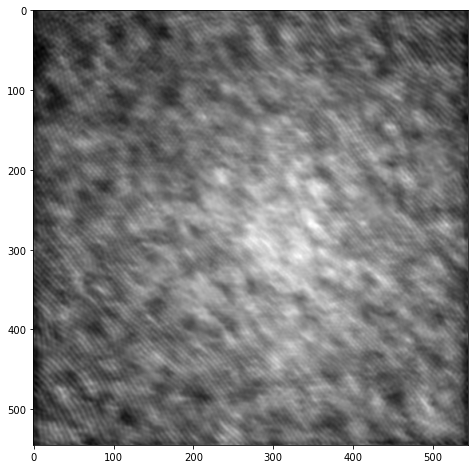

In [12]:
psf = numpy.abs(aotools.ft2(padded_pupil, delta=diameter/array_size))**2
aberrated_image = scipy.signal.convolve2d(image, psf, mode='same',boundary='wrap')

plt.figure(figsize=(8,8))
plt.imshow(aberrated_image,cmap='gray')

This is a very simple convolution, which is probably sufficient for non-scanning non-confocal retinal imaging systems.  In systems such as the AOSLO, however, it is not this simple as we have a system with a confocal pinhole.  